In [2]:
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

import os
import sys
import logging

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [25]:
adata_infile = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/stream_outs/female_traj_fast2b.h5ad"
out_tmp = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/stream_outs'

In [26]:
from os.path import basename
import stream as st
#read the stream result file pkl or h5ad
adata = st.read(file_name=adata_infile, workdir=out_tmp)

Working directory is already specified as '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/stream_outs' 
To change working directory, please run set_workdir(adata,workdir=new_directory)


### Plotting cell type specific trajectories

In [96]:
adata_subset = adata[adata.obs['C_scANVI'] == 'Fast IIX']
adata_subset = adata_subset.copy()

In [27]:
adata_subset = adata  

In [98]:
# Check if your data is sparse (imputed data is dense, normalized data is sparse)
import scipy.sparse as sp

if sp.issparse(adata_subset.X):
    adata_subset.X = adata_subset.X.toarray()

In [99]:
print(type(adata_subset.X))
print(adata_subset.X.shape)

<class 'numpy.ndarray'>
(13900, 3000)


#### Filter cells if not using imputed data

In [100]:
st.cal_qc(adata_subset,assay='rna')

In [101]:
st.filter_cells(adata_subset,min_n_features= 150, assay='rna')
st.filter_features(adata_subset,min_n_cells = 10, assay='rna')

filter cells based on min_n_features
after filtering out low-quality cells: 
9083 cells, 3000 genes
Filter genes based on min_n_cells
After filtering out low-expressed genes: 
9083 cells, 2051 genes


In [102]:
###Remove mitochondrial genes 
st.remove_mt_genes(adata_subset)

In [103]:
adata_subset.obs['condition'].value_counts()

KO    4730
WT    4353
Name: condition, dtype: int64

In [ ]:
#adata_subset.X = adata_subset.layers['MAGIC_imputed_data']

103 variable genes are selected


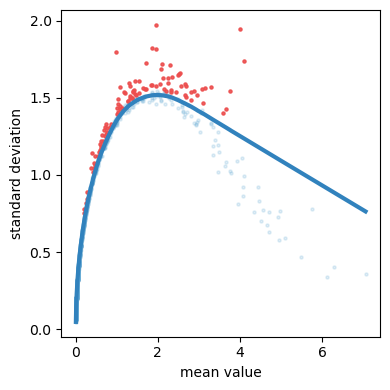

In [104]:
st.select_variable_genes(adata_subset,loess_frac=0.05,percentile=95)

In [105]:
# # 'var_genes' vs 'all' : use top % or all genes from .var ; if using all make sure the adata is subsetted to only the highly variable genes
# # n_components = Number of branches present in your biological differentation (min 2 dimensions for plotting, 3 would make it 3D)
# # method = 'se' or 'mlle' standard LLE or modified LLE
st.dimension_reduction(adata_subset,method='se',feature='var_genes',n_components=2,n_neighbors=30,n_jobs=64) # using the same knn as diffusion maps (default is 30)

feature var_genes is being used ...
64 cpus are being used ...


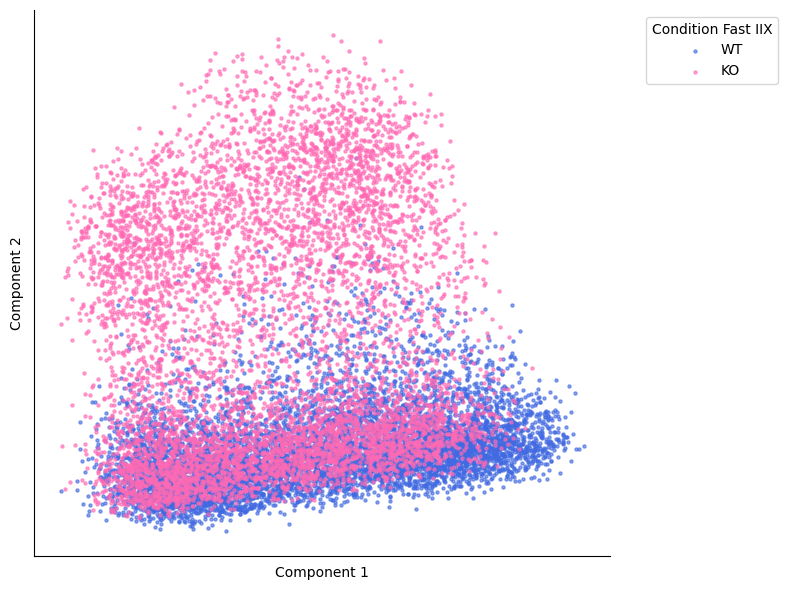

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Color dictionary for conditions
condition_color_dict = {
    'WT': '#4169E1',     # royal blue
    'KO': '#FF69B4'      # hot pink
}

# Ensure condition is categorical
adata_subset.obs['condition'] = pd.Categorical(
    adata_subset.obs['condition'],
    categories=['WT', 'KO'],
    ordered=True
)

# Extract coordinates from the 'X_dr'/'X_mlle' slot 
coords = adata_subset.obsm['X_dr']  # or 'X_mlle'

# Extract the labels for coloring
labels = adata_subset.obs['condition']

# Get unique labels and their corresponding colors
unique_labels = labels.cat.categories  # Use .cat.categories to maintain order
color_list = [condition_color_dict[label] for label in unique_labels]

# Plotting with colors based on condition
plt.figure(figsize=(8, 6))
for label, color in zip(unique_labels, color_list):
    idx = labels == label
    plt.scatter(coords[idx, 0], coords[idx, 1], c=color, label=label, s=5, alpha=0.6)

# Remove ticks
plt.xticks([])
plt.yticks([])

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.title('')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(title="Condition Fast IIX", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# plt.savefig('/your/path/condition_plot.pdf', 
#             bbox_inches='tight',
#             dpi=300,
#             format='pdf')

plt.show()

In [107]:
# make stream adata compatible with h5ad for saving

adata_to_save = adata_subset.copy()

# Find and remove ALL incompatible objects from .uns
keys_to_remove = []
for key, val in adata_to_save.uns.items():
    # Check if it's a type that h5ad can handle
    compatible = False
    
    if val is None:
        compatible = True
    elif isinstance(val, (str, int, float, bool)):
        compatible = True
    elif isinstance(val, np.ndarray):
        compatible = True
    elif isinstance(val, pd.DataFrame):
        compatible = True
    elif isinstance(val, dict):
        # Dicts might have nested incompatible objects, but we'll try
        compatible = True
    elif isinstance(val, list):
        compatible = True
    
    if not compatible:
        keys_to_remove.append(key)
        print(f"Will remove '{key}': {type(val)}")

# Remove incompatible keys
for key in keys_to_remove:
    del adata_to_save.uns[key]

# Also convert any pandas Index to list/array in remaining dicts
for key, val in list(adata_to_save.uns.items()):
    if isinstance(val, pd.Index):
        adata_to_save.uns[key] = val.tolist()
        print(f"Converted '{key}' from Index to list")


Will remove 'neighbors': <class 'anndata.compat._overloaded_dict.OverloadedDict'>
Will remove 'var_genes': <class 'pandas.core.indexes.base.Index'>
Will remove 'trans_se': <class 'sklearn.manifold._spectral_embedding.SpectralEmbedding'>


In [108]:
# save adata_subset to pkl
adata_to_save.write_h5ad(os.path.join(out_tmp,'male_traj_fast2x.h5ad'), compression='gzip')

#### Save traj with pseudotime

Saving results in: /tmp/tmp3y67zts_
Seeding initial elastic principal graph...
Clustering...
K-Means clustering ...
The number of initial nodes is 10
Calculatng minimum spanning tree...
Number of initial branches: 3
Learning elastic principal graph...
[1]
 "Constructing tree 1 of 1 / Subset 1 of 1"


[1]
 "Computing EPG with 50 nodes on 14482 points and 2 dimensions"


[1]
 "Using a single core"


Nodes = 
10
 
11
 
12
 
13
 
14
 
15
 
16
 
17
 
18
 
19
 
20
 
21
 
22
 
23
 
24
 
25
 
26
 
27
 
28
 
29
 
30
 
31
 
32
 
33
 
34
 
35
 
36
 
37
 
38
 
39
 
40
 
41
 
42
 
43
 
44
 
45
 
46
 
47
 
48
 
49
 


BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD

0||50
	
3.212e-07
	
50
	
49
	
48
	
0
	
0
	
0
	
2.099e-07
	
2.025e-07
	
0.9566
	
0.9581
	
1.002e-07
	
1.106e-08
	
5.531e-07
	
2.765e-05
	
0


35.816 sec elapsed

[[1]]



Number of branches after learning elastic principal graph: 1
Extending leaves with additional nodes ...
Number of branches a

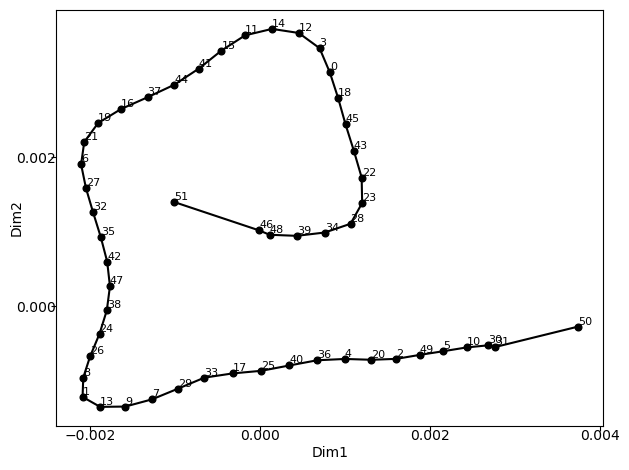

In [29]:
import os
os.environ["OMP_NUM_THREADS"] = "64"
from tempfile import TemporaryDirectory
from rpy2.robjects import r
# Load the rlang package in R
r('library(rlang)')

# Parameters for STREAM (tune to your dataset)
ka1={'epg_alpha':0.02,'epg_mu':0.07,'epg_lambda':0.02,'epg_trimmingradius':2} # epg_mu needs to be tuned to get a good branch for day-1 to activated and undefined cells
ka2={'epg_ext_mode':'QuantDists','epg_ext_par':1.}

# Trajectory inference
with TemporaryDirectory() as td:
	st.set_workdir(adata,td)
	st.seed_elastic_principal_graph(adata,n_clusters=10)
	st.elastic_principal_graph(adata,**ka1)
	st.extend_elastic_principal_graph(adata,**ka2)

st.optimize_branching(adata,incr_n_nodes=30) #smoothen out the branches
st.plot_branches(adata,show_text=True)

In [15]:
st.extend_elastic_principal_graph(adata, epg_ext_mode='WeigthedCentroid',epg_ext_par=0.8)

Extending leaves with additional nodes ...
Number of branches after extending leaves: 3


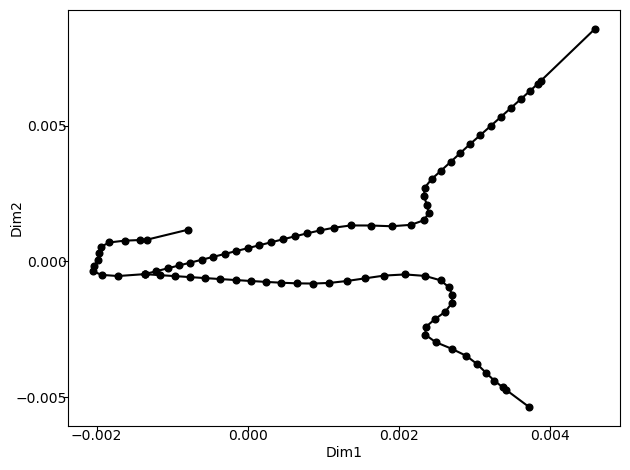

In [16]:
st.plot_branches(adata,show_text=False)

In [17]:
adata.obs.head()

,sample_id,cell_type,condition,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,kmeans,node,branch_id,branch_id_alias,branch_lam,branch_dist,S0_pseudotime,S3_pseudotime,S2_pseudotime,S1_pseudotime
AAACCCAAGAACCCGA-1,M4_KO,Fast IIB,KO,0.046261,0.999385,3193.803711,1.058075,1283,7.157735,2471,...,cluster 9,78,"(83, 0)","(S3, S0)",0.008659,0.000024,0.000500,0.008659,0.003534,0.012282
AAACGAACAGGACGAT-1,M4_KO,Fast IIB,KO,0.055986,0.999097,3384.720215,1.073799,1348,7.207119,2680,...,cluster 9,75,"(83, 0)","(S3, S0)",0.008555,0.000102,0.000604,0.008555,0.003639,0.012386
AAACGCTGTACGACAG-1,M4_KO,Fast IIB,KO,0.046217,0.999546,3296.336182,1.144022,1302,7.172425,2783,...,cluster 1,81,"(83, 0)","(S3, S0)",0.008970,0.000127,0.000189,0.008970,0.003223,0.011971
AAACGCTGTGATTCTG-1,M4_KO,Fast IIB,KO,0.031072,0.999955,4050.485352,1.273136,1725,7.453562,4082,...,cluster 4,72,"(85, 0)","(S1, S0)",0.010516,0.000017,0.001266,0.010425,0.004300,0.010516
AAACGCTGTGGTAACG-1,M4_KO,Fast IIB,KO,0.064846,0.999439,3372.492432,1.001404,1233,7.118016,2464,...,cluster 4,84,"(84, 0)","(S2, S0)",0.000000,0.000409,0.003034,0.012193,0.000000,0.014816


In [19]:
adata.obs['condition_color'] = adata.obs['condition'].map(condition_color_dict)

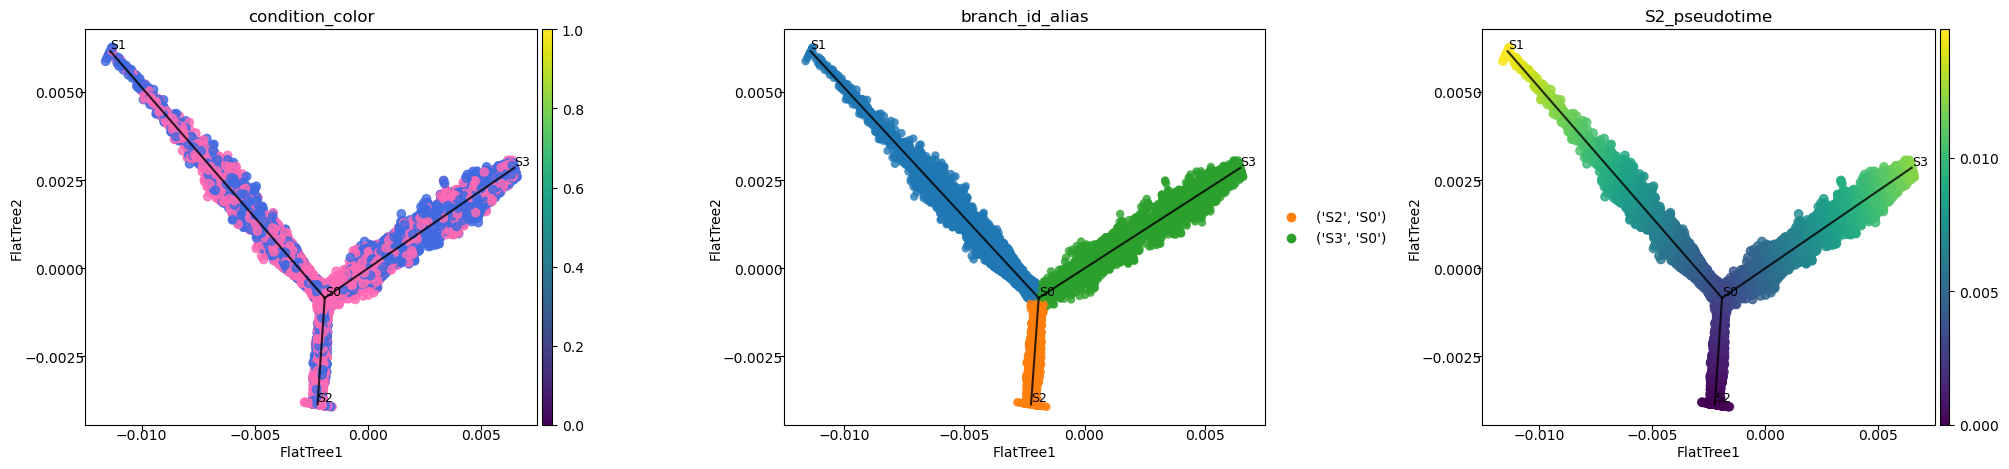

In [22]:
st.plot_flat_tree(adata,color=['condition_color','branch_id_alias','S2_pseudotime'],
                  dist_scale=0.5,show_graph=True,show_text=True)

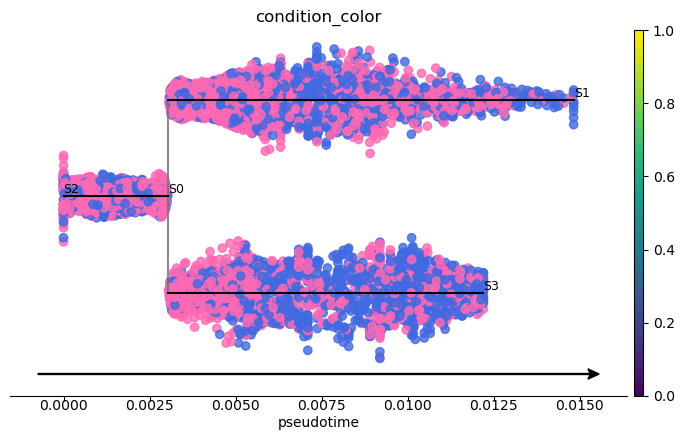

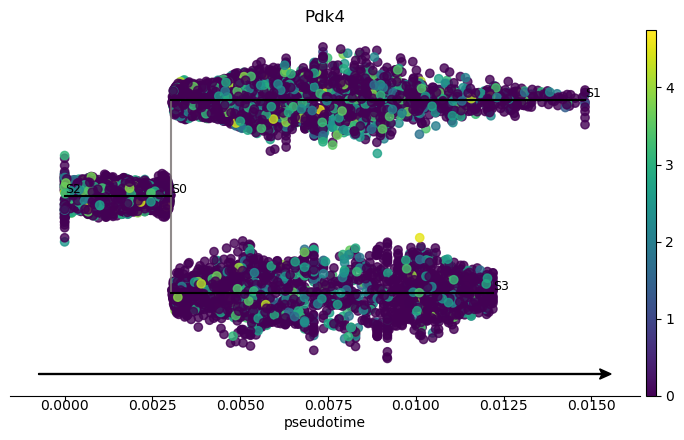

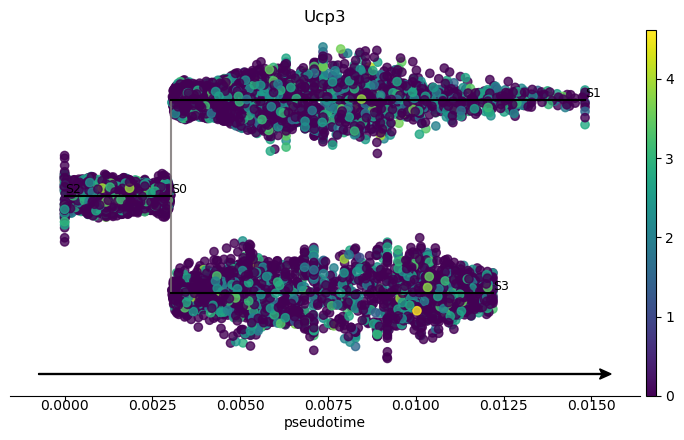

In [24]:
st.plot_stream_sc(adata,root='S2',color=['condition_color','Pdk4', 'Ucp3'],
                  dist_scale=0.3,show_graph=True,show_text=True)